In [1]:
import layers
import modules
import tensorflow as tf
import keras
import numpy as np
import matplotlib.pyplot as plt
import scipy.io as sio
from scipy.signal import resample_poly
from scipy.signal import butter, sosfiltfilt
from pathlib import Path
from sklearn.model_selection import train_test_split
import os
import json
import pandas as pd
from tensorflow.keras.callbacks import ModelCheckpoint

from AF_metrics_utils import *


from scipy import signal
from scipy.stats import pearsonr
from typing import Tuple, Dict, List

In [2]:
class DopplerClinicalMetrics:
    """
    Calculate clinically relevant metrics from fetal Doppler envelopes.
    """
    
    def __init__(self, sampling_rate=284):
        """
        Parameters:
        -----------
        sampling_rate : int
            Sampling rate in Hz (default 284 Hz based on your pipeline)
        """
        self.fs = sampling_rate
        
    def detect_peaks_and_troughs(self, envelope: np.ndarray, 
                                  min_distance_samples: int = None) -> Tuple[np.ndarray, np.ndarray]:
        """
        Detect systolic peaks and diastolic troughs in Doppler envelope.
        
        Parameters:
        -----------
        envelope : np.ndarray
            Doppler envelope signal (1D)
        min_distance_samples : int, optional
            Minimum samples between peaks (default: 0.3s worth of samples)
            
        Returns:
        --------
        peak_indices : np.ndarray
            Indices of systolic peaks
        trough_indices : np.ndarray
            Indices of diastolic troughs
        """
        if min_distance_samples is None:
            # Assume fetal HR ~120-160 bpm, so ~0.4-0.5s between beats
            min_distance_samples = int(0.3 * self.fs)
        
        # Find peaks (systolic)
        peak_indices, _ = signal.find_peaks(envelope, 
                                            distance=min_distance_samples,
                                            prominence=0.1 * np.ptp(envelope))
        
        # Find troughs (diastolic) - invert signal
        trough_indices, _ = signal.find_peaks(-envelope, 
                                              distance=min_distance_samples,
                                              prominence=0.1 * np.ptp(envelope))
        
        return peak_indices, trough_indices
    
    def calculate_pulsatility_index(self, envelope: np.ndarray) -> float:
        """
        Calculate Pulsatility Index (PI).
        PI = (PSV - EDV) / TAMX
        
        Normal fetal umbilical artery PI: 0.8-1.2 (decreases with gestational age)
        """
        peak_indices, trough_indices = self.detect_peaks_and_troughs(envelope)
        
        if len(peak_indices) < 2 or len(trough_indices) < 1:
            return np.nan
        
        # Peak Systolic Velocity (PSV)
        psv = np.mean(envelope[peak_indices])
        
        # End Diastolic Velocity (EDV) - value just before next systole
        edv_values = []
        for i, peak_idx in enumerate(peak_indices[:-1]):
            next_peak = peak_indices[i + 1]
            # Find trough between current and next peak
            troughs_between = trough_indices[(trough_indices > peak_idx) & 
                                            (trough_indices < next_peak)]
            if len(troughs_between) > 0:
                edv_values.append(envelope[troughs_between[-1]])
        
        if len(edv_values) == 0:
            return np.nan
            
        edv = np.mean(edv_values)
        
        # Time-Averaged Maximum Velocity
        tamx = np.mean(envelope)
        
        if tamx == 0:
            return np.nan
            
        pi = (psv - edv) / tamx
        return pi
    
    def calculate_resistance_index(self, envelope: np.ndarray) -> float:
        """
        Calculate Resistance Index (RI).
        RI = (PSV - EDV) / PSV
        
        Normal fetal umbilical artery RI: 0.6-0.8 (decreases with gestational age)
        """
        peak_indices, trough_indices = self.detect_peaks_and_troughs(envelope)
        
        if len(peak_indices) < 2 or len(trough_indices) < 1:
            return np.nan
        
        psv = np.mean(envelope[peak_indices])
        
        edv_values = []
        for i, peak_idx in enumerate(peak_indices[:-1]):
            next_peak = peak_indices[i + 1]
            troughs_between = trough_indices[(trough_indices > peak_idx) & 
                                            (trough_indices < next_peak)]
            if len(troughs_between) > 0:
                edv_values.append(envelope[troughs_between[-1]])
        
        if len(edv_values) == 0 or psv == 0:
            return np.nan
            
        edv = np.mean(edv_values)
        ri = (psv - edv) / psv
        return ri
    
    def calculate_sd_ratio(self, envelope: np.ndarray) -> float:
        """
        Calculate Systolic/Diastolic (S/D) Ratio.
        S/D = PSV / EDV
        
        Normal fetal umbilical artery S/D: 2.0-4.0 (decreases with gestational age)
        High S/D ratio (>3.0 in third trimester) suggests placental insufficiency
        """
        peak_indices, trough_indices = self.detect_peaks_and_troughs(envelope)
        
        if len(peak_indices) < 2 or len(trough_indices) < 1:
            return np.nan
        
        psv = np.mean(envelope[peak_indices])
        
        edv_values = []
        for i, peak_idx in enumerate(peak_indices[:-1]):
            next_peak = peak_indices[i + 1]
            troughs_between = trough_indices[(trough_indices > peak_idx) & 
                                            (trough_indices < next_peak)]
            if len(troughs_between) > 0:
                edv_values.append(envelope[troughs_between[-1]])
        
        if len(edv_values) == 0 or np.mean(edv_values) == 0:
            return np.nan
            
        edv = np.mean(edv_values)
        sd_ratio = psv / edv
        return sd_ratio
    
    def calculate_heart_rate(self, envelope: np.ndarray) -> float:
        """
        Calculate heart rate from peak-to-peak intervals.
        
        Returns:
        --------
        heart_rate : float
            Heart rate in beats per minute (bpm)
        """
        peak_indices, _ = self.detect_peaks_and_troughs(envelope)
        
        if len(peak_indices) < 2:
            return np.nan
        
        # Calculate intervals between peaks
        intervals = np.diff(peak_indices) / self.fs  # in seconds
        avg_interval = np.mean(intervals)
        
        if avg_interval == 0:
            return np.nan
        
        heart_rate = 60.0 / avg_interval  # Convert to bpm
        return heart_rate
    
    def calculate_peak_systolic_velocity(self, envelope: np.ndarray) -> float:
        """Calculate average peak systolic velocity."""
        peak_indices, _ = self.detect_peaks_and_troughs(envelope)
        
        if len(peak_indices) == 0:
            return np.nan
        
        return np.mean(envelope[peak_indices])
    
    def calculate_end_diastolic_velocity(self, envelope: np.ndarray) -> float:
        """Calculate average end diastolic velocity."""
        peak_indices, trough_indices = self.detect_peaks_and_troughs(envelope)
        
        if len(peak_indices) < 2 or len(trough_indices) < 1:
            return np.nan
        
        edv_values = []
        for i, peak_idx in enumerate(peak_indices[:-1]):
            next_peak = peak_indices[i + 1]
            troughs_between = trough_indices[(trough_indices > peak_idx) & 
                                            (trough_indices < next_peak)]
            if len(troughs_between) > 0:
                edv_values.append(envelope[troughs_between[-1]])
        
        if len(edv_values) == 0:
            return np.nan
        
        return np.mean(edv_values)
    
    def calculate_all_metrics(self, envelope: np.ndarray) -> Dict[str, float]:
        """
        Calculate all clinical metrics for a single envelope.
        
        Returns:
        --------
        metrics : dict
            Dictionary containing all calculated metrics
        """
        metrics = {
            'PI': self.calculate_pulsatility_index(envelope),
            'RI': self.calculate_resistance_index(envelope),
            'SD_Ratio': self.calculate_sd_ratio(envelope),
            'Heart_Rate': self.calculate_heart_rate(envelope),
            'PSV': self.calculate_peak_systolic_velocity(envelope),
            'EDV': self.calculate_end_diastolic_velocity(envelope),
            'TAMX': np.mean(envelope)
        }
        return metrics


def evaluate_clinical_metrics(real_envelopes: np.ndarray, 
                              generated_envelopes: np.ndarray,
                              sampling_rate: int = 284,
                              model_name: str = "Model") -> pd.DataFrame:
    """
    Evaluate clinical metrics for real vs generated Doppler envelopes.
    
    Parameters:
    -----------
    real_envelopes : np.ndarray
        Ground truth envelopes, shape (n_samples, sequence_length)
    generated_envelopes : np.ndarray
        Generated envelopes, shape (n_samples, sequence_length)
    sampling_rate : int
        Sampling rate in Hz
    model_name : str
        Name of the model for reporting
        
    Returns:
    --------
    comparison_df : pd.DataFrame
        DataFrame with comparison statistics for each metric
    """
    calculator = DopplerClinicalMetrics(sampling_rate=sampling_rate)
    
    n_samples = real_envelopes.shape[0]
    
    # Initialize storage for metrics
    real_metrics = {key: [] for key in ['PI', 'RI', 'SD_Ratio', 'Heart_Rate', 'PSV', 'EDV', 'TAMX']}
    gen_metrics = {key: [] for key in ['PI', 'RI', 'SD_Ratio', 'Heart_Rate', 'PSV', 'EDV', 'TAMX']}
    
    print(f"Calculating clinical metrics for {model_name}...")
    print(f"Processing {n_samples} segments...\n")
    
    # Calculate metrics for each segment
    for i in range(n_samples):
        # Real envelope
        real_m = calculator.calculate_all_metrics(real_envelopes[i])
        for key, val in real_m.items():
            real_metrics[key].append(val)
        
        # Generated envelope
        gen_m = calculator.calculate_all_metrics(generated_envelopes[i])
        for key, val in gen_m.items():
            gen_metrics[key].append(val)
        
        if (i + 1) % 100 == 0:
            print(f"Processed {i + 1}/{n_samples} segments...")
    
    # Calculate comparison statistics
    results = []
    
    for metric_name in real_metrics.keys():
        real_vals = np.array(real_metrics[metric_name])
        gen_vals = np.array(gen_metrics[metric_name])
        
        # Remove NaN pairs
        valid_mask = ~(np.isnan(real_vals) | np.isnan(gen_vals))
        real_vals_valid = real_vals[valid_mask]
        gen_vals_valid = gen_vals[valid_mask]
        
        if len(real_vals_valid) == 0:
            results.append({
                'Metric': metric_name,
                'Real_Mean': np.nan,
                'Real_Std': np.nan,
                'Generated_Mean': np.nan,
                'Generated_Std': np.nan,
                'MAE': np.nan,
                'RMSE': np.nan,
                'Correlation': np.nan,
                'Valid_Samples': 0
            })
            continue
        
        # Calculate statistics
        mae = np.mean(np.abs(real_vals_valid - gen_vals_valid))
        rmse = np.sqrt(np.mean((real_vals_valid - gen_vals_valid) ** 2))
        
        if len(real_vals_valid) > 1 and np.std(real_vals_valid) > 0 and np.std(gen_vals_valid) > 0:
            corr, _ = pearsonr(real_vals_valid, gen_vals_valid)
        else:
            corr = np.nan
        
        results.append({
            'Metric': metric_name,
            'Real_Mean': np.mean(real_vals_valid),
            'Real_Std': np.std(real_vals_valid),
            'Generated_Mean': np.mean(gen_vals_valid),
            'Generated_Std': np.std(gen_vals_valid),
            'MAE': mae,
            'RMSE': rmse,
            'Correlation': corr,
            'Valid_Samples': len(real_vals_valid)
        })
    
    comparison_df = pd.DataFrame(results)
    
    # Print summary
    print(f"\n{'='*80}")
    print(f"Clinical Metrics Evaluation - {model_name}")
    print(f"{'='*80}\n")
    print(comparison_df.to_string(index=False))
    print(f"\n{'='*80}\n")
    
    return comparison_df


def plot_clinical_metrics_comparison(real_envelopes: np.ndarray,
                                     generated_envelopes: np.ndarray,
                                     sampling_rate: int = 284,
                                     model_name: str = "Model",
                                     save_path: str = None):
    """
    Create visualization comparing clinical metrics between real and generated envelopes.
    
    Parameters:
    -----------
    real_envelopes : np.ndarray
        Ground truth envelopes
    generated_envelopes : np.ndarray
        Generated envelopes
    sampling_rate : int
        Sampling rate in Hz
    model_name : str
        Name of the model
    save_path : str, optional
        Path to save the figure
    """
    calculator = DopplerClinicalMetrics(sampling_rate=sampling_rate)
    
    n_samples = real_envelopes.shape[0]
    
    # Calculate metrics
    metrics_names = ['PI', 'RI', 'SD_Ratio', 'Heart_Rate']
    real_metrics = {key: [] for key in metrics_names}
    gen_metrics = {key: [] for key in metrics_names}
    
    for i in range(n_samples):
        real_m = calculator.calculate_all_metrics(real_envelopes[i])
        gen_m = calculator.calculate_all_metrics(generated_envelopes[i])
        
        for key in metrics_names:
            real_metrics[key].append(real_m[key])
            gen_metrics[key].append(gen_m[key])
    
    # Create figure with subplots
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
    
    for idx, metric_name in enumerate(metrics_names):
        ax = axes[idx]
        
        real_vals = np.array(real_metrics[metric_name])
        gen_vals = np.array(gen_metrics[metric_name])
        
        # Remove NaN values
        valid_mask = ~(np.isnan(real_vals) | np.isnan(gen_vals))
        real_vals = real_vals[valid_mask]
        gen_vals = gen_vals[valid_mask]
        
        if len(real_vals) == 0:
            ax.text(0.5, 0.5, 'No valid data', ha='center', va='center')
            ax.set_title(metric_name)
            continue
        
        # Scatter plot
        ax.scatter(real_vals, gen_vals, alpha=0.5, s=20, edgecolors='black', linewidth=0.5)
        
        # Identity line
        min_val = min(real_vals.min(), gen_vals.min())
        max_val = max(real_vals.max(), gen_vals.max())
        ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect agreement')
        
        # Calculate correlation
        if np.std(real_vals) > 0 and np.std(gen_vals) > 0:
            corr, _ = pearsonr(real_vals, gen_vals)
            ax.text(0.05, 0.95, f'r = {corr:.3f}', transform=ax.transAxes,
                   fontsize=11, verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        
        ax.set_xlabel(f'Real {metric_name}', fontsize=11, fontweight='bold')
        ax.set_ylabel(f'Generated {metric_name}', fontsize=11, fontweight='bold')
        ax.set_title(f'{metric_name} Comparison', fontsize=12, fontweight='bold')
        ax.legend(loc='lower right', fontsize=9)
        ax.grid(True, alpha=0.3)
    
    plt.suptitle(f'Clinical Metrics Comparison - {model_name}', 
                 fontsize=14, fontweight='bold', y=0.995)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Figure saved to {save_path}")
    
    return fig, axes


def plot_bland_altman(real_envelopes: np.ndarray,
                     generated_envelopes: np.ndarray,
                     sampling_rate: int = 284,
                     model_name: str = "Model",
                     save_path: str = None):
    """
    Create Bland-Altman plots for clinical metrics (gold standard for clinical agreement).
    
    Parameters:
    -----------
    real_envelopes : np.ndarray
        Ground truth envelopes
    generated_envelopes : np.ndarray
        Generated envelopes
    sampling_rate : int
        Sampling rate in Hz
    model_name : str
        Name of the model
    save_path : str, optional
        Path to save the figure
    """
    calculator = DopplerClinicalMetrics(sampling_rate=sampling_rate)
    
    n_samples = real_envelopes.shape[0]
    
    # Calculate metrics
    metrics_names = ['PI', 'RI', 'SD_Ratio', 'Heart_Rate']
    real_metrics = {key: [] for key in metrics_names}
    gen_metrics = {key: [] for key in metrics_names}
    
    for i in range(n_samples):
        real_m = calculator.calculate_all_metrics(real_envelopes[i])
        gen_m = calculator.calculate_all_metrics(generated_envelopes[i])
        
        for key in metrics_names:
            real_metrics[key].append(real_m[key])
            gen_metrics[key].append(gen_m[key])
    
    # Create Bland-Altman plots
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
    
    for idx, metric_name in enumerate(metrics_names):
        ax = axes[idx]
        
        real_vals = np.array(real_metrics[metric_name])
        gen_vals = np.array(gen_metrics[metric_name])
        
        # Remove NaN values
        valid_mask = ~(np.isnan(real_vals) | np.isnan(gen_vals))
        real_vals = real_vals[valid_mask]
        gen_vals = gen_vals[valid_mask]
        
        if len(real_vals) == 0:
            ax.text(0.5, 0.5, 'No valid data', ha='center', va='center')
            ax.set_title(metric_name)
            continue
        
        # Bland-Altman calculations
        mean_vals = (real_vals + gen_vals) / 2
        diff_vals = gen_vals - real_vals
        mean_diff = np.mean(diff_vals)
        std_diff = np.std(diff_vals)
        
        # Plot
        ax.scatter(mean_vals, diff_vals, alpha=0.5, s=20, edgecolors='black', linewidth=0.5)
        
        # Mean difference line
        ax.axhline(mean_diff, color='blue', linestyle='-', linewidth=2, label=f'Mean: {mean_diff:.3f}')
        
        # Limits of agreement (±1.96 SD)
        upper_loa = mean_diff + 1.96 * std_diff
        lower_loa = mean_diff - 1.96 * std_diff
        ax.axhline(upper_loa, color='red', linestyle='--', linewidth=2, label=f'+1.96 SD: {upper_loa:.3f}')
        ax.axhline(lower_loa, color='red', linestyle='--', linewidth=2, label=f'-1.96 SD: {lower_loa:.3f}')
        
        # Zero line
        ax.axhline(0, color='black', linestyle=':', linewidth=1, alpha=0.5)
        
        ax.set_xlabel(f'Mean of Real and Generated {metric_name}', fontsize=11, fontweight='bold')
        ax.set_ylabel(f'Difference (Generated - Real)', fontsize=11, fontweight='bold')
        ax.set_title(f'{metric_name} Bland-Altman Plot', fontsize=12, fontweight='bold')
        ax.legend(loc='best', fontsize=9)
        ax.grid(True, alpha=0.3)
    
    plt.suptitle(f'Bland-Altman Analysis - {model_name}', 
                 fontsize=14, fontweight='bold', y=0.995)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Figure saved to {save_path}")
    
    return fig, axes

In [3]:
train_idx = np.load('/home/tsu25/ECG_PWD/Fetal-maternal-fusion/src/idx_train.npy')
val_idx = np.load('/home/tsu25/ECG_PWD/Fetal-maternal-fusion/src/idx_val.npy')
RISK_GROUPS = np.load('/home/tsu25/ECG_PWD/single_channel/src/WaveNet_beat/data/RISK_GROUPS.npy')

# Load the generated data
two_ch_generated = np.load('/home/tsu25/ECG_PWD/Fetal-maternal-fusion/src/WaveNet_beat/generated_data/final_two_ch_model_generated_dopplers.npy')
one_ch_generated = np.load('/home/tsu25/ECG_PWD/single_channel/src/WaveNet_beat/generated_data/final_one_ch_model_generated_dopplers.npy')
comp_fusion = np.load('/home/tsu25/ECG_PWD/Fetal-maternal-fusion/src/WaveNet_beat/generated_data/comp_model_dopplers_v2.npy')

Y = np.load('/home/tsu25/ECG_PWD/single_channel/src/WaveNet_beat/data/Y.npy')
selected_real_dopplers = Y[val_idx]
real_dopplers = selected_real_dopplers

In [14]:
RISK_GROUPS

array(['no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no',
       'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no',
       'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no',
       'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no',
       'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no',
       'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no',
       'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no',
       'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no',
       'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no',
       'no', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes',
       'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes',
       'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes',
       'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes',
       'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', '

In [4]:
def smooth_all_segments(real_dopplers, fs=284, cutoff_hz=10.0, order=4):
    n_segments, seq_length = real_dopplers.shape
    smoothed_dopplers = np.zeros_like(real_dopplers)
    for i in range(n_segments):
        smoothed_dopplers[i] = smooth_doppler_envelope(
            real_dopplers[i], 
            fs=fs, 
            cutoff_hz=cutoff_hz, 
            order=order
        )
    return smoothed_dopplers

def visualize_smoothing_comparison(real_dopplers, smoothed_dopplers, 
                                   segment_indices=[0, 1, 2], fs=284):
    n_segments = len(segment_indices)
    seq_length = real_dopplers.shape[1]
    time_axis = np.arange(seq_length) / fs  # Convert to seconds
    
    fig, axes = plt.subplots(n_segments, 1, figsize=(14, 4 * n_segments))
    
    if n_segments == 1:
        axes = [axes]
    
    for idx, seg_idx in enumerate(segment_indices):
        ax = axes[idx]
        
        # Plot original
        ax.plot(time_axis, real_dopplers[seg_idx], 
                label='Original', alpha=0.7, linewidth=1.5, color='blue')
        
        # Plot smoothed
        ax.plot(time_axis, smoothed_dopplers[seg_idx], 
                label='Smoothed', linewidth=2, color='red')
        
        ax.set_xlabel('Time (s)', fontsize=12)
        ax.set_ylabel('Doppler Envelope', fontsize=12)
        ax.set_title(f'Segment {seg_idx}: Original vs Smoothed', fontsize=14)
        ax.legend(fontsize=11)
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

In [5]:
def sos_bandpass(lowcut, highcut, fs, order=2):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    # output = sos for numerically stable; use zero-phase via sosfiltfilt
    return butter(order, [low, high], btype='bandpass', output='sos')

def ecg_bandpass_zero_phase(x, fs, lowcut=0.5, highcut=40.0, order=2):
    sos = sos_bandpass(lowcut, highcut, fs, order=order)
    # zero-phase (acausal) filtering for offline learning
    return sosfiltfilt(sos, x)

def butter_lowpass_sos(cutoff_hz: float, fs: float, order: int = 4):
    """
    A Butterworth low-pass in second-order sections (SOS) for doppler envelopes
    cutoff_hz : cutoff frequency in Hz
    fs_hz     : sampling rate in Hz
    order     : filter order
    """
    sos = butter(order, cutoff_hz, btype='low', fs=fs, output='sos')
    return sos

def smooth_doppler_envelope(env: np.ndarray, fs: float,
                            cutoff_hz: float = 10.0, order: int = 4) -> np.ndarray:
    # Zero-phase smoothing of a Doppler envelope.
    sos = butter_lowpass_sos(cutoff_hz, fs, order=order)
    return sosfiltfilt(sos, env)

def normalize_signal(signal):
    # Normalize the signal to the range [-1, 1]
    signal_min = np.min(signal)
    signal_max = np.max(signal)
    normalized_signal = 2 * (signal - signal_min) / (signal_max - signal_min) - 1
    return normalized_signal

def ECG_preprocess(ecg_signal, fs):
    """
    Apply ECG preprocessing functions to fetal and maternal ECG signals
    """
    filtered_ecg = DUS_filtering(ecg_signal, fs)
    normalized_ecg = normalize_signal(filtered_ecg)
    return normalized_ecg

In [6]:
smoothed_single = smooth_all_segments(
        one_ch_generated, 
        fs=284, 
        cutoff_hz=10.0, 
        order=4
    )

smoothed_fusion = smooth_all_segments(
        two_ch_generated, 
        fs=284, 
        cutoff_hz=10.0, 
        order=4
    )

smoothed_comp = smooth_all_segments(
        comp_fusion, 
        fs=284, 
        cutoff_hz=10.0, 
        order=4
    )

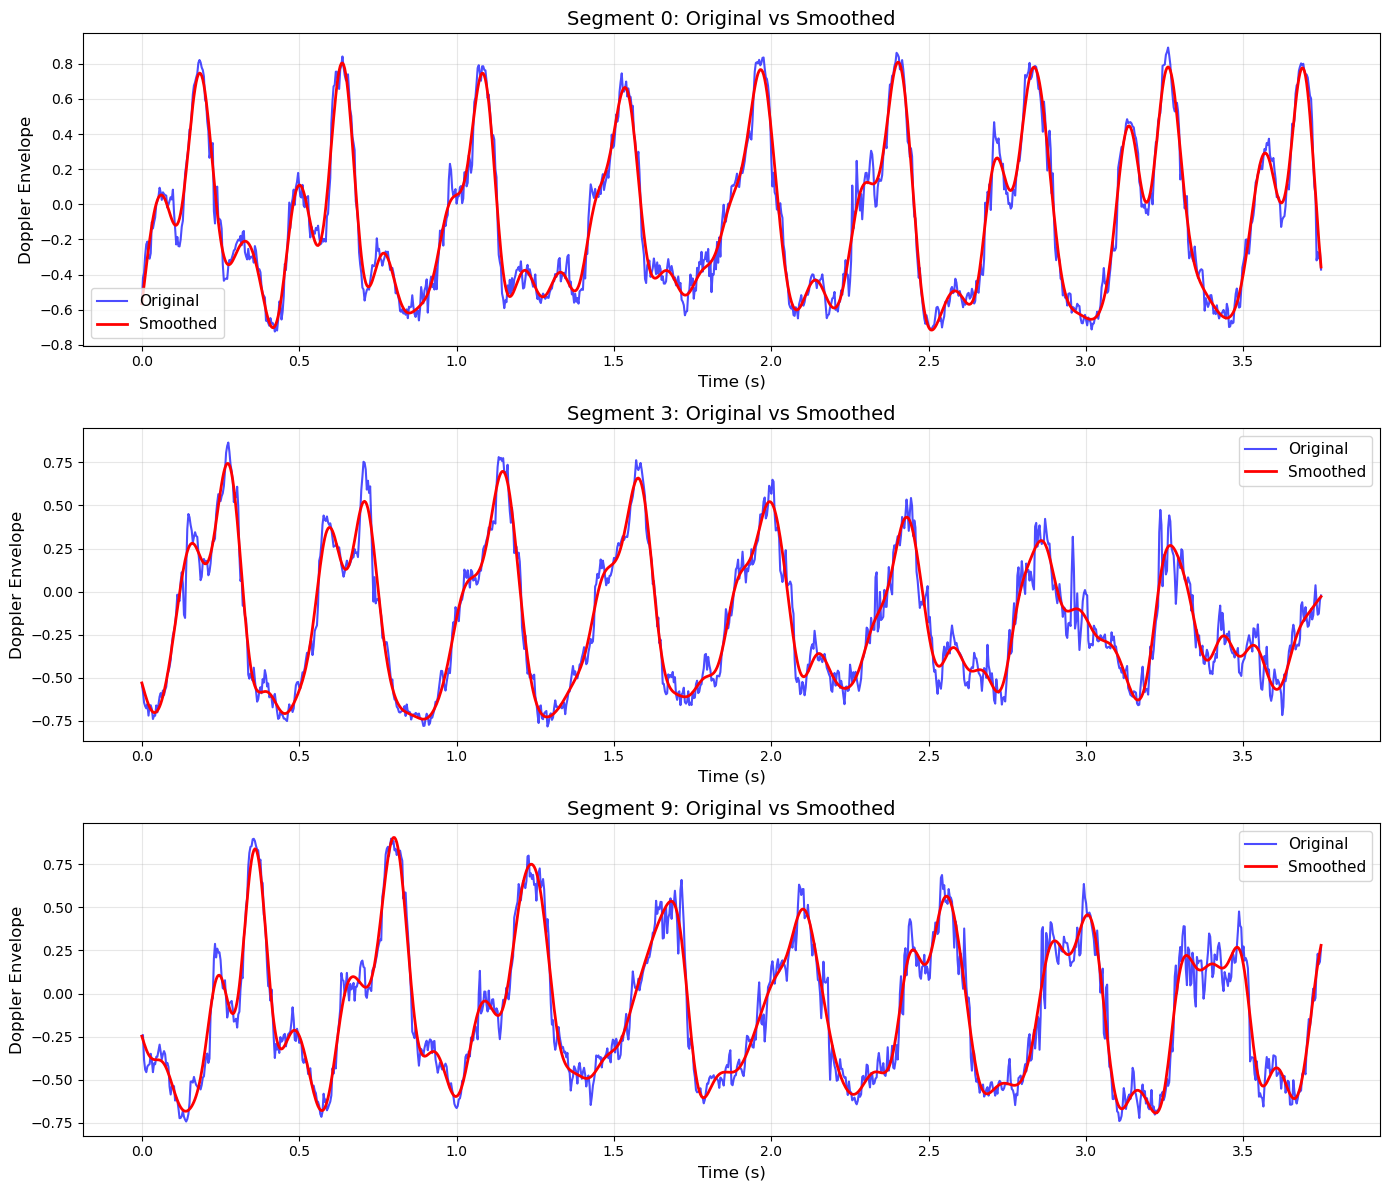

In [7]:
visualize_smoothing_comparison(
    two_ch_generated, 
    smoothed_fusion, 
    segment_indices=[0, 3, 9], 
    fs=284
)

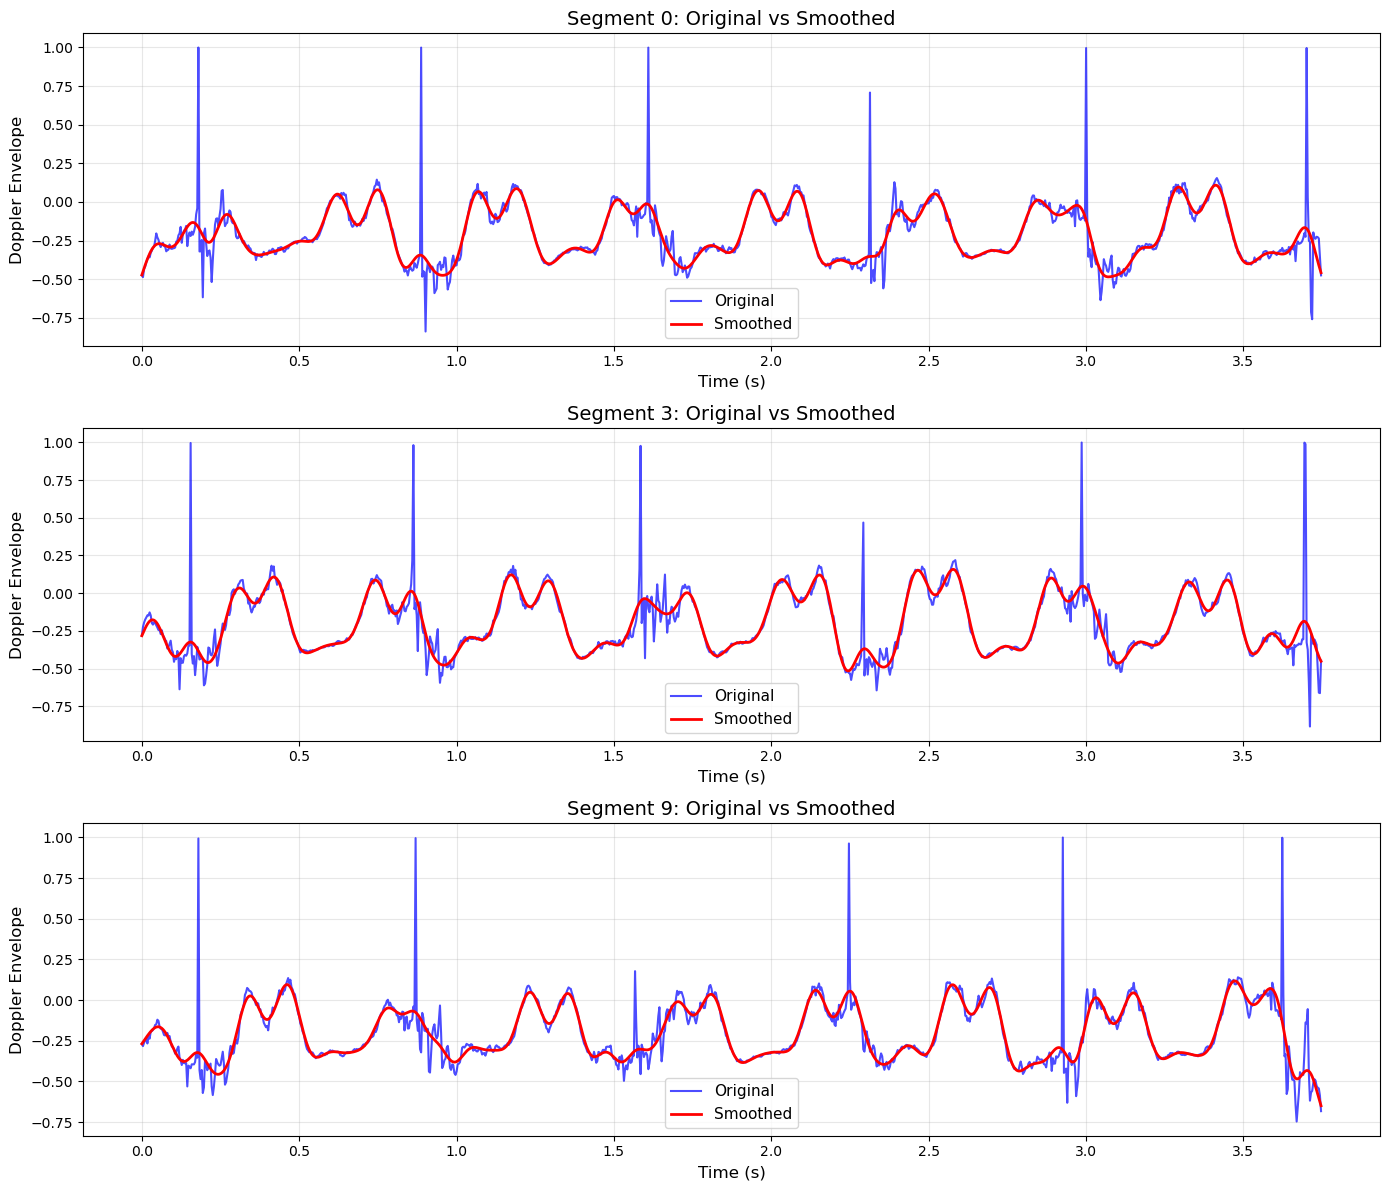

In [8]:
visualize_smoothing_comparison(
    comp_fusion, 
    smoothed_comp, 
    segment_indices=[0, 3, 9], 
    fs=284
)

In [10]:
Y = np.load('/home/tsu25/ECG_PWD/Fetal-maternal-fusion/src/WaveNet_beat/data/Y.npy')
X = np.load('/home/tsu25/ECG_PWD/Fetal-maternal-fusion/src/WaveNet_beat/data/X.npy')

selected_ecgs = X[val_idx]

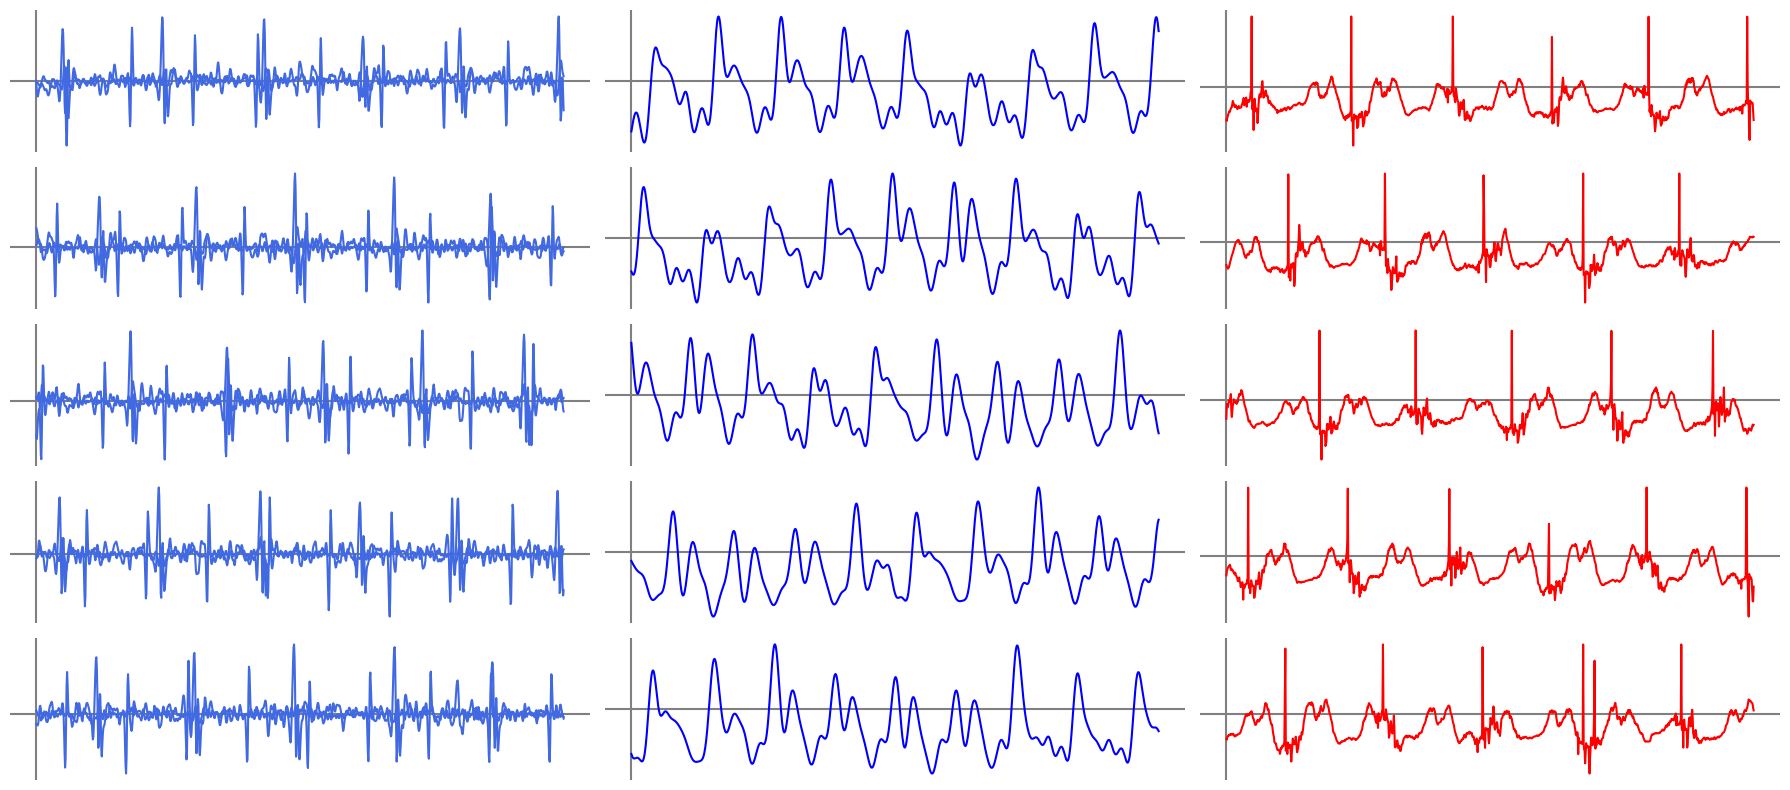

In [11]:
modules.plot_ecg_doppler_pairs(selected_ecgs[:5], selected_real_dopplers[:5], comp_fusion[:5])

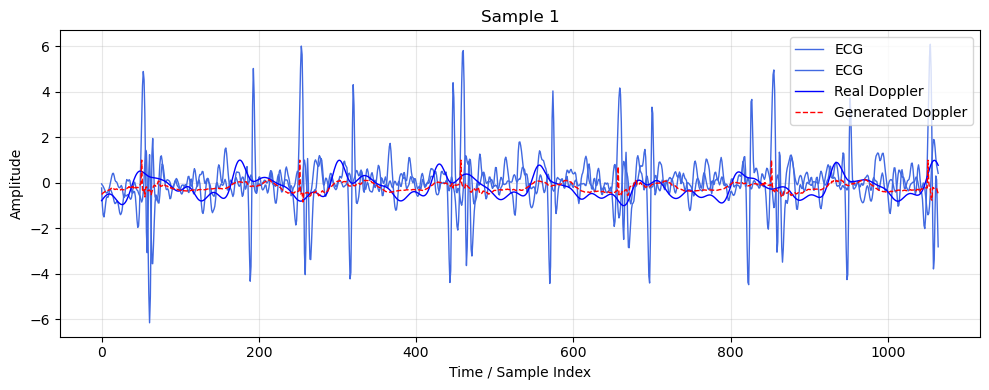

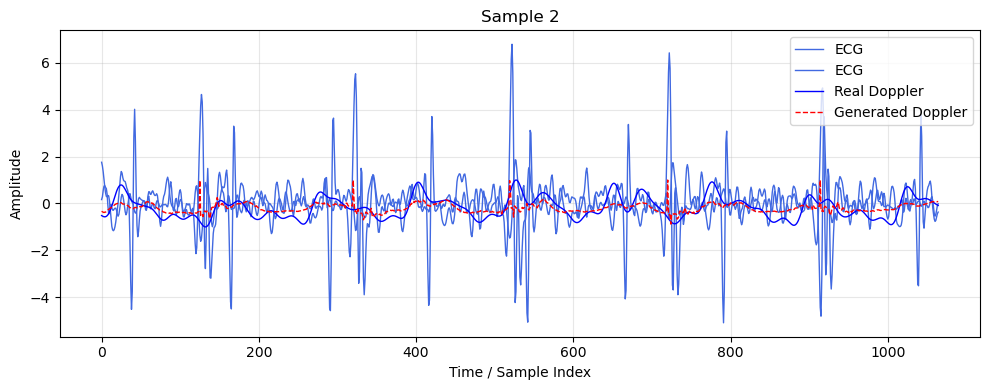

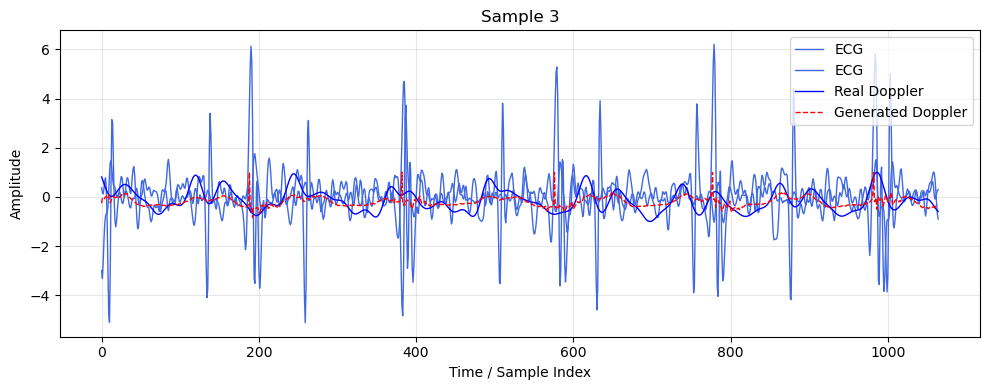

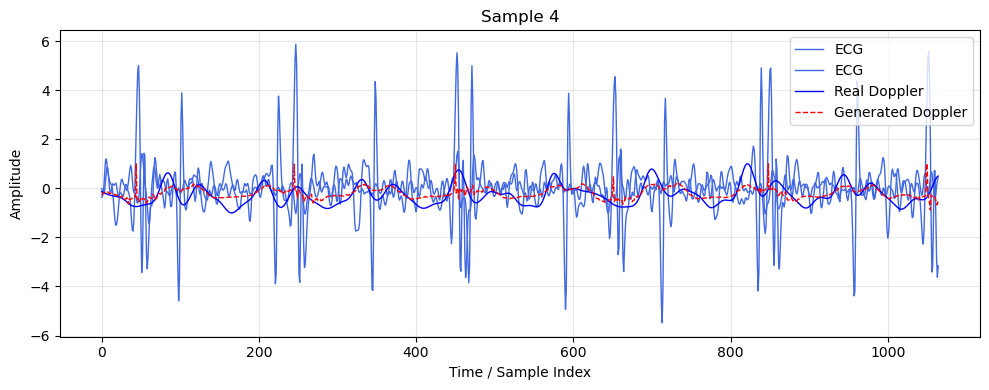

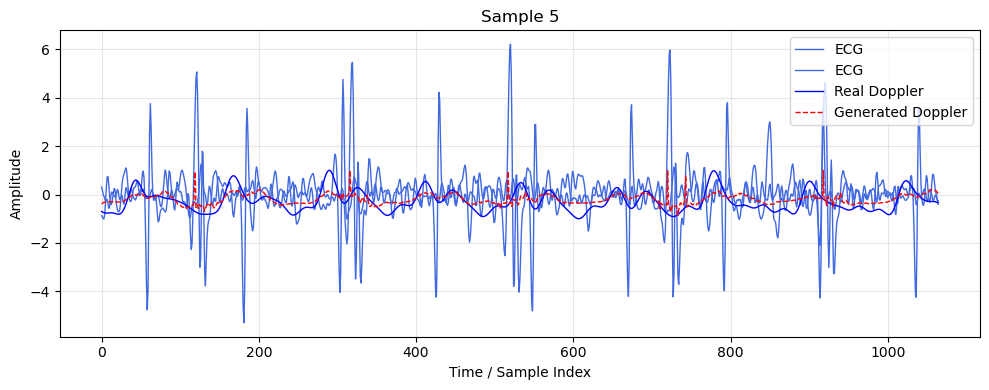

In [13]:
modules.plot_ecg_doppler_overlay(selected_ecgs[:5], selected_real_dopplers[:5], comp_fusion[:5])

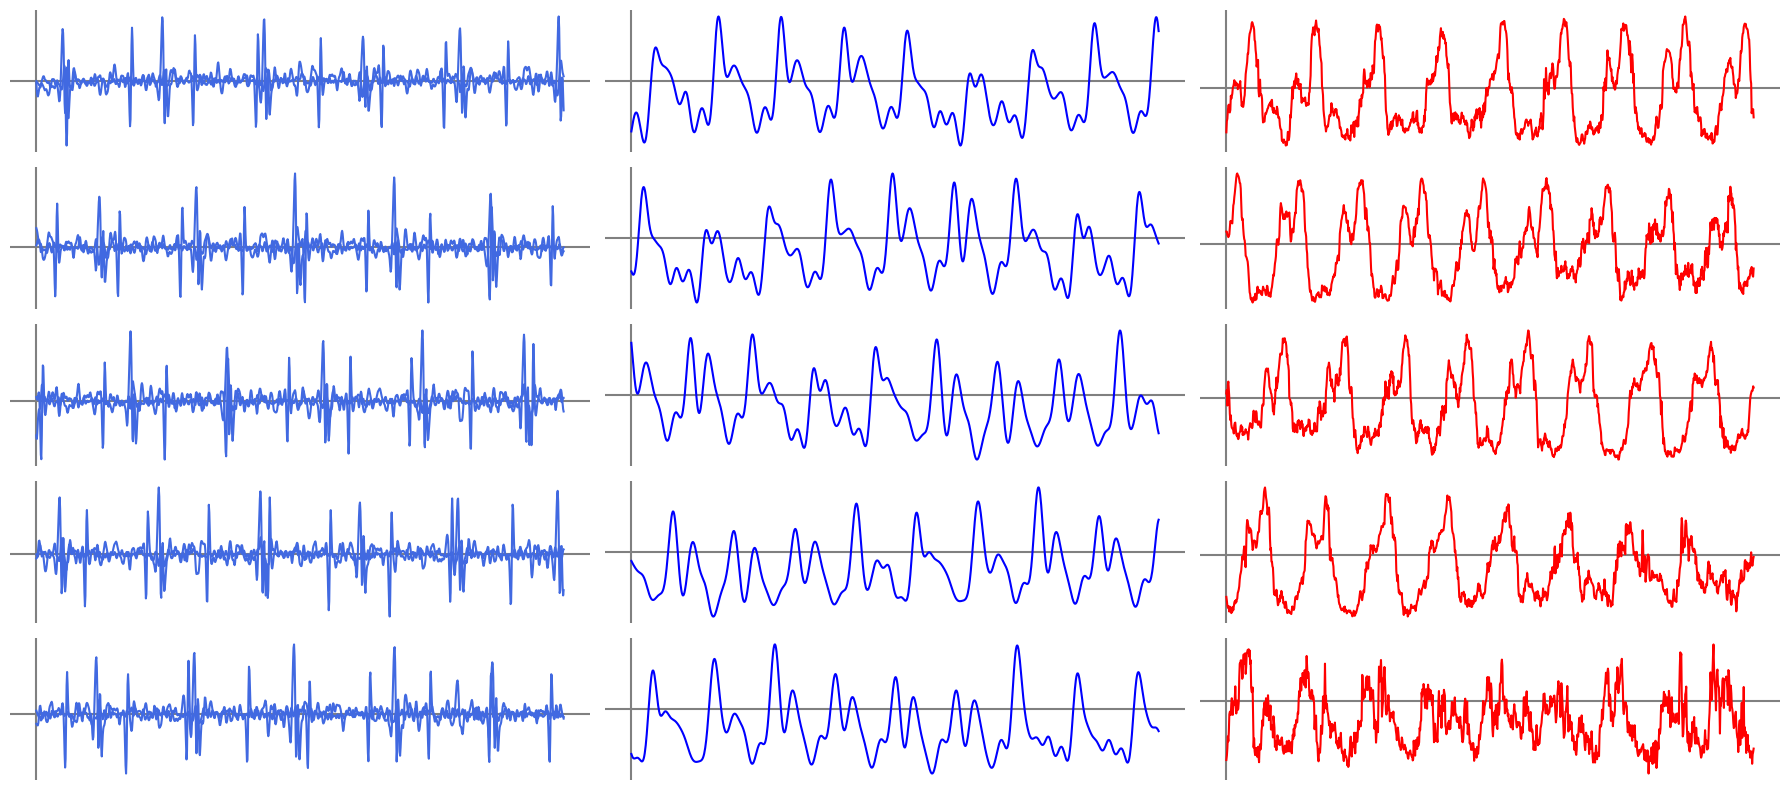

In [12]:
modules.plot_ecg_doppler_pairs(selected_ecgs[:5], selected_real_dopplers[:5], two_ch_generated[:5])

Calculating clinical metrics for Two-Channel WaveNet...
Processing 192 segments...

Processed 100/192 segments...

Clinical Metrics Evaluation - Two-Channel WaveNet

    Metric  Real_Mean  Real_Std  Generated_Mean  Generated_Std       MAE       RMSE  Correlation  Valid_Samples
        PI  -3.944923 54.223972      -13.316425     107.231483 39.685055 119.941139     0.012106            192
        RI   2.230270  0.601867        2.173170       0.375548  0.362853   0.664097     0.144927            192
  SD_Ratio  -0.888190  0.219269       -0.922218       0.233306  0.221203   0.288970     0.197085            192
Heart_Rate 142.569301  7.760774      142.649737       7.829733  3.567244   6.048511     0.699059            192
       PSV   0.752533  0.142371        0.562807       0.155045  0.220788   0.263972     0.240628            192
       EDV  -0.865254  0.110785       -0.612348       0.098988  0.262313   0.289716     0.095666            192
      TAMX  -0.179770  0.133659       -0.099231   

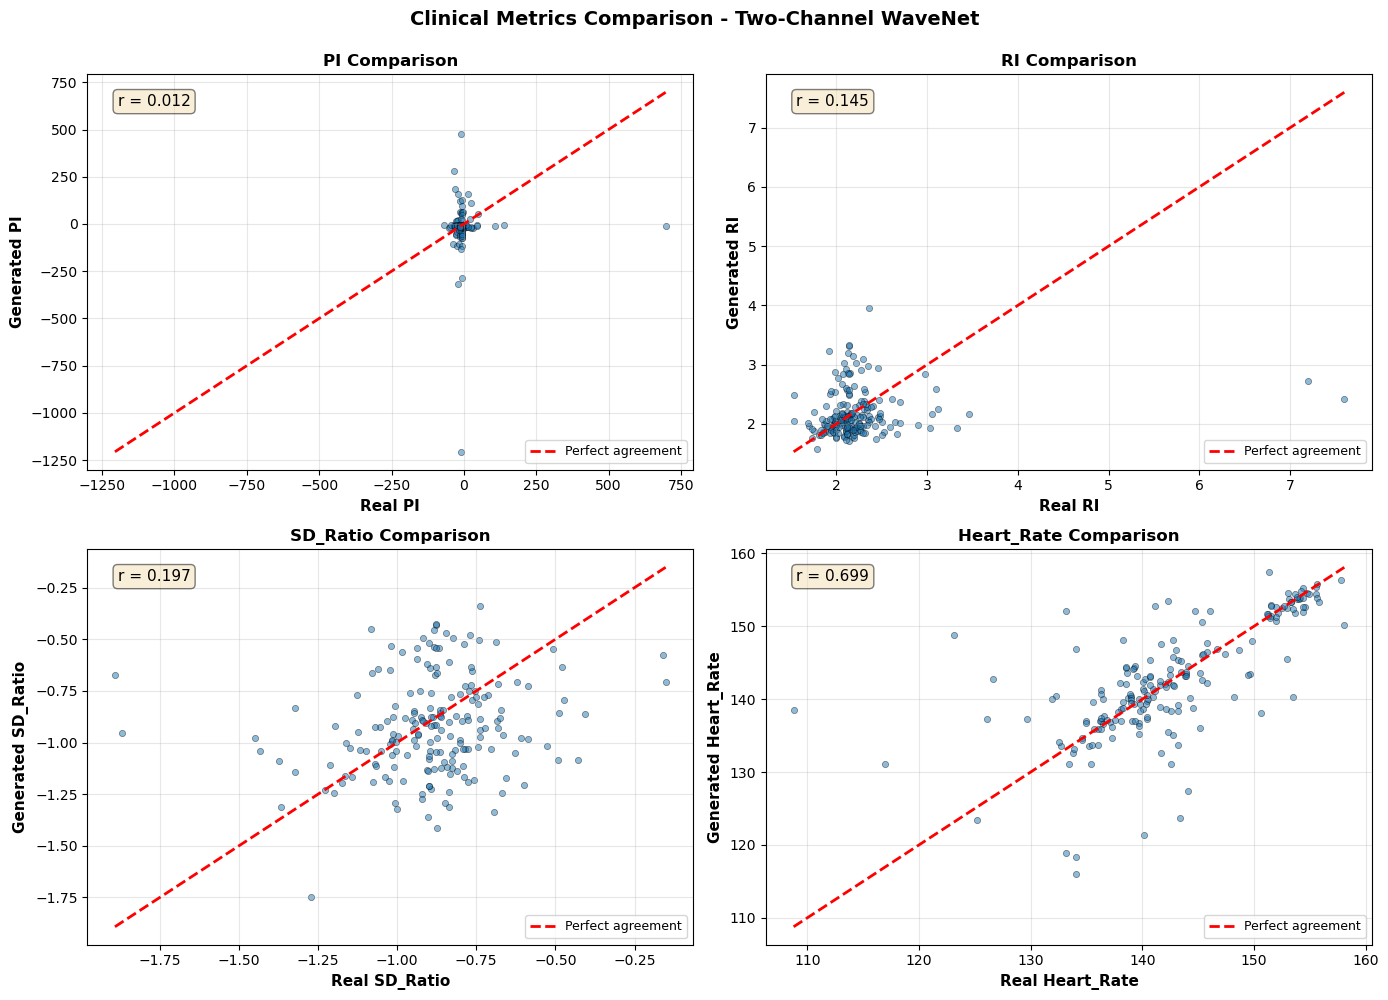

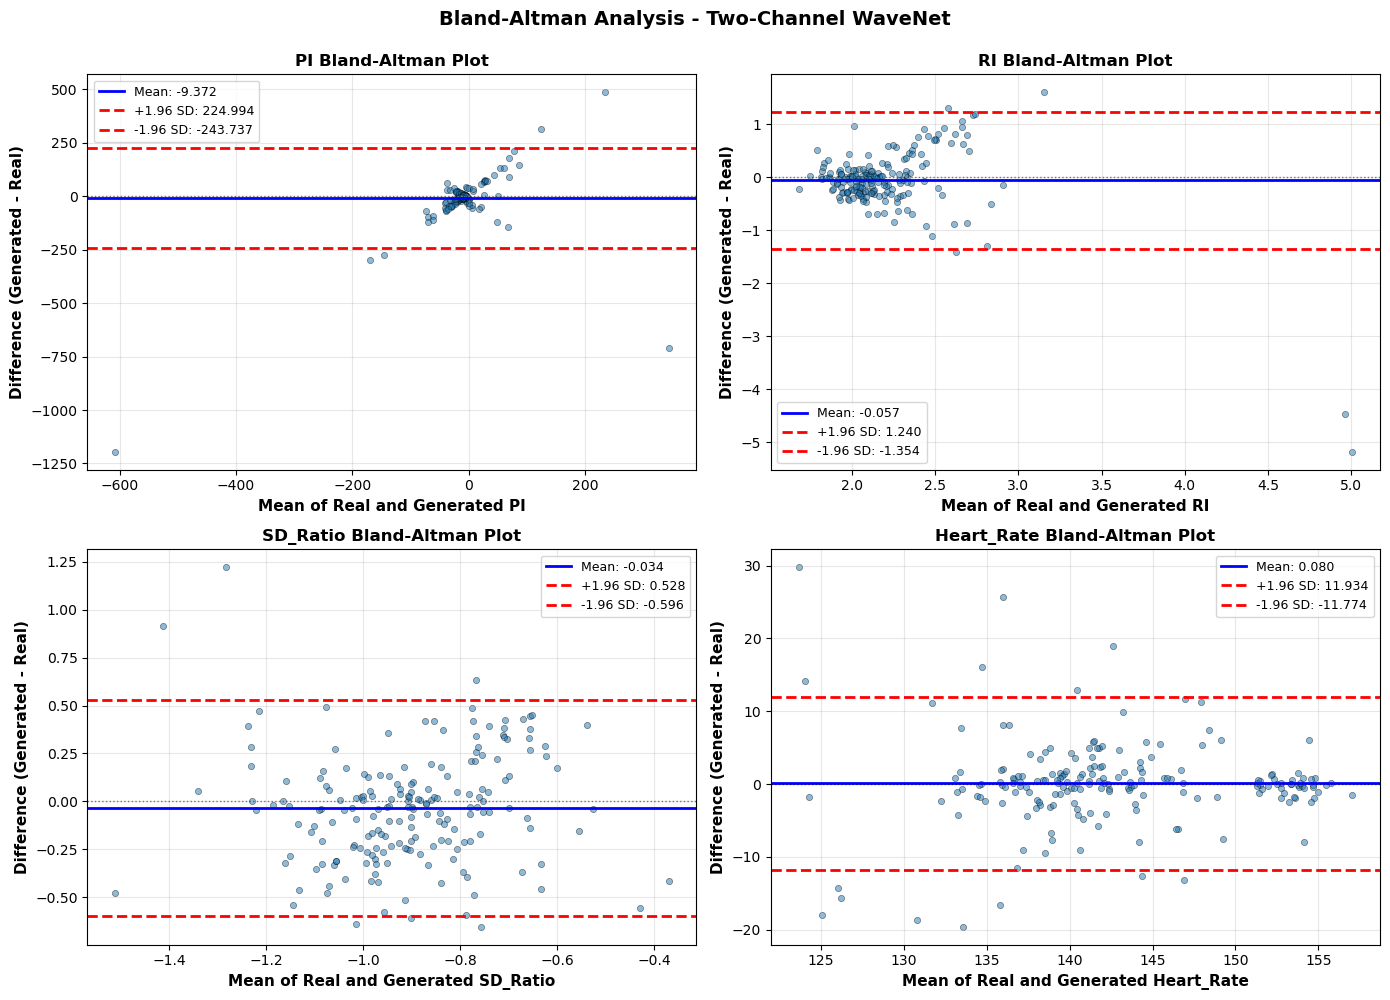

In [11]:
# Evaluate clinical metrics
comparison_df = evaluate_clinical_metrics(
    selected_real_dopplers, 
    smoothed_fusion,
    sampling_rate=284,
    model_name="Two-Channel WaveNet"
)
#comparison_df.to_csv('clinical_metrics_comparison.csv', index=False)

# Create visualizations
fig1, ax1 = plot_clinical_metrics_comparison(
    selected_real_dopplers,
    smoothed_fusion,
    sampling_rate=284,
    model_name="Two-Channel WaveNet"
)

fig2, ax2 = plot_bland_altman(
    selected_real_dopplers,
    smoothed_fusion,
    sampling_rate=284,
    model_name="Two-Channel WaveNet"
)

plt.show()

Calculating clinical metrics for One-Channel WaveNet...
Processing 192 segments...

Processed 100/192 segments...

Clinical Metrics Evaluation - One-Channel WaveNet

    Metric  Real_Mean  Real_Std  Generated_Mean  Generated_Std       MAE      RMSE  Correlation  Valid_Samples
        PI  -3.944923 54.223972       -6.109245       3.023741 14.114842 54.293049     0.019307            192
        RI   2.230270  0.601867        2.891003       2.841184  1.085118  2.971621     0.011873            192
  SD_Ratio  -0.888190  0.219269       -0.663125       0.230598  0.303759  0.391954    -0.017004            192
Heart_Rate 142.569301  7.760774      142.399254       7.235538  3.514240  6.155682     0.665313            192
       PSV   0.752533  0.142371        0.380970       0.157973  0.384631  0.430761    -0.050478            192
       EDV  -0.865254  0.110785       -0.558415       0.077922  0.311792  0.330800     0.177625            192
      TAMX  -0.179770  0.133659       -0.174356       0.0

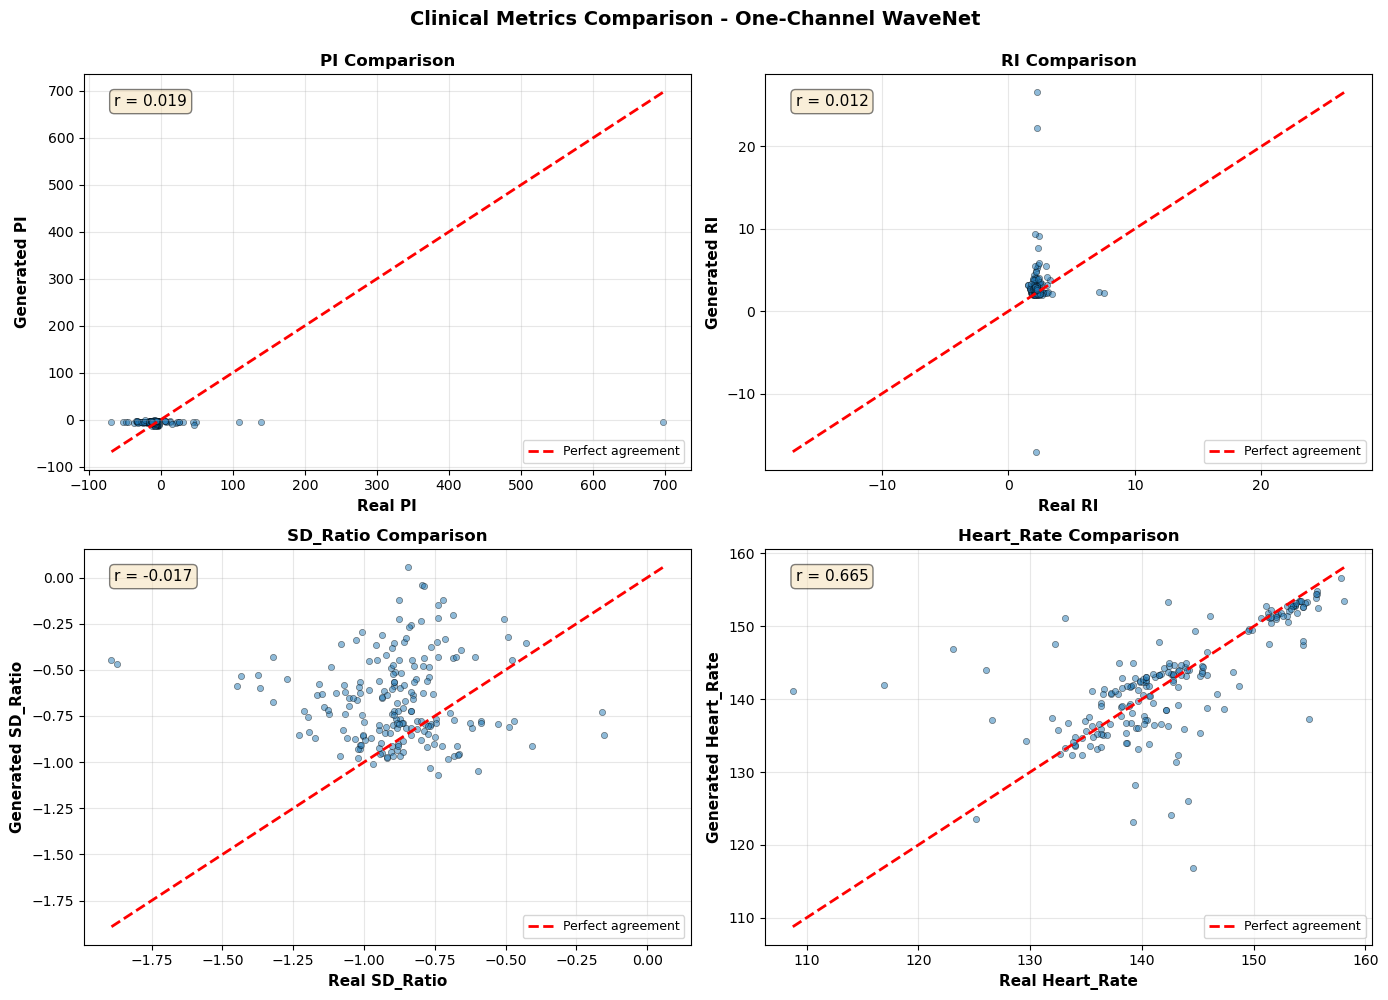

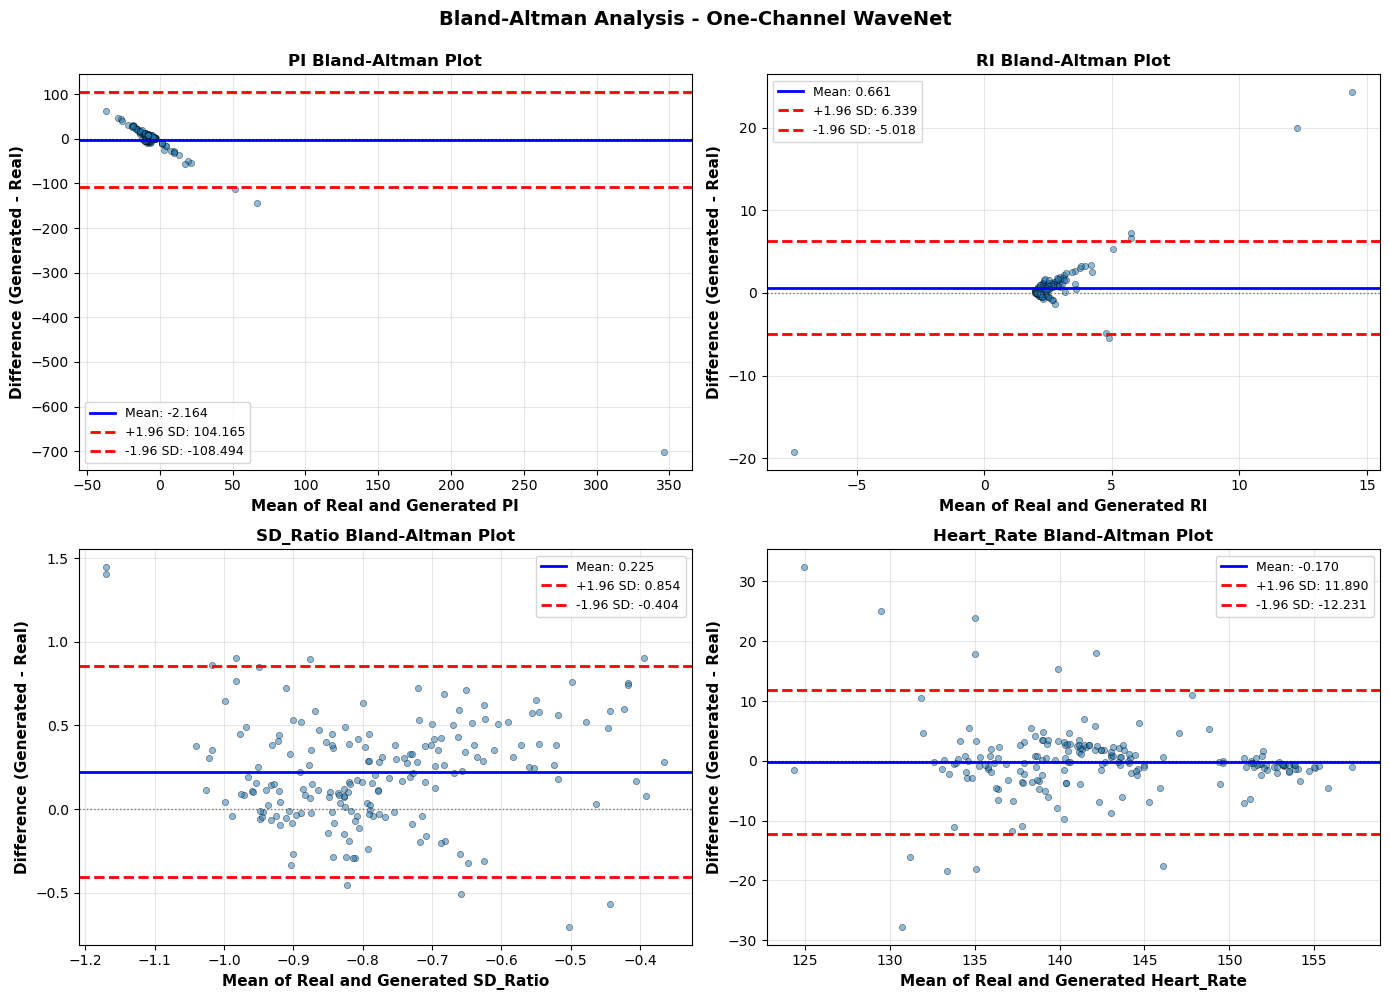

In [12]:
# Evaluate clinical metrics
comparison_df = evaluate_clinical_metrics(
    selected_real_dopplers, 
    smoothed_single,
    sampling_rate=284,
    model_name="One-Channel WaveNet"
)
#comparison_df.to_csv('clinical_metrics_comparison.csv', index=False)

# Create visualizations
fig1, ax1 = plot_clinical_metrics_comparison(
    selected_real_dopplers,
    smoothed_single,
    sampling_rate=284,
    model_name="One-Channel WaveNet"
)

fig2, ax2 = plot_bland_altman(
    selected_real_dopplers,
    smoothed_single,
    sampling_rate=284,
    model_name="One-Channel WaveNet"
)

plt.show()